# Calibration statistics for the curling Q-network and value network

This demo loads both existing score networks, builds their corresponding evaluation datasets, computes the same statistics, and plots categorical calibration for each one.

In [8]:
import importlib
import logging
from pathlib import Path
import sys

# Keep Matplotlib's font discovery and other diagnostics out of the notebook output.
logging.basicConfig(level=logging.ERROR, format='%(message)s')
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

import matplotlib.pyplot as plt

# Make imports work whether the notebook is launched from the repository root
# or from scratch/.
repo_root = Path.cwd()
if not (repo_root / 'curling_nn.py').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import calibration
import dataset
import nn
import curling_nn
import stats
from constants import q_network_weights_path, value_network_weights_path

# Reload in dependency order so rerunning this notebook after source changes
# cannot leave ScoreNetwork inheriting from an older NN class.
importlib.reload(nn)
importlib.reload(curling_nn)
importlib.reload(stats)
importlib.reload(calibration)

<module 'curling_nn' from '/home/vietafan/curling/curling_nn.py'>

In [9]:
# Load both existing models and their feature normalizers.
q_network, q_normalizer = curling_nn.load_q_weights(q_network_weights_path)
value_network, value_normalizer = curling_nn.load_v_weights(value_network_weights_path)
for name, network, normalizer in [
    ('Q', q_network, q_normalizer),
    ('value', value_network, value_normalizer),
]: 
    print(
        f'{name} network: {network.num_stones} input stones, '
        f'{network.num_stones_per_side * 2 + 1} score outputs, '
        f'{normalizer.feature_means.size} input features'
    )

Q network: 9 input stones, 11 score outputs, 52 input features
value network: 8 input stones, 11 score outputs, 41 input features


## Build an evaluation dataset

The Q-network uses random sheet states plus throws sampled as in `training.ipynb`. The value network uses the project helper that generates final scores after an optimal grid-searched second-to-last and last throw. Each saved model's normalizer is applied to its raw features.

In [8]:
q_evaluation_data = dataset.load_training_data(
    repo_root / 'scratch/q_calibration_evaluation.npz'
)
v_evaluation_data = dataset.load_training_data(
    repo_root / 'scratch/value_calibration_evaluation.npz'
)
print(f'Q-network evaluation examples: {q_evaluation_data.size()}')
print(f'value-network evaluation examples: {v_evaluation_data.size()}')

evaluation examples: 8200


In [7]:
q_stats = calibration.evaluate_model(q_network, q_evaluation_data, seed=2026)
value_stats = calibration.evaluate_model(value_network, v_evaluation_data, seed=2026)

print('Q network:')
stats.print_stats(q_stats)
print('Value network:')
stats.print_stats(value_stats)

Q network:
  expected-score R²: 0.041 ± 0.000
  P(actual score): 0.194 ± 0.003
  negative log P(actual): 3.626 ± 0.049
value network:
  expected-score R²: -7.941 ± 0.038
  P(actual score): 0.017 ± 0.011
  negative log P(actual): 8.875 ± 0.403


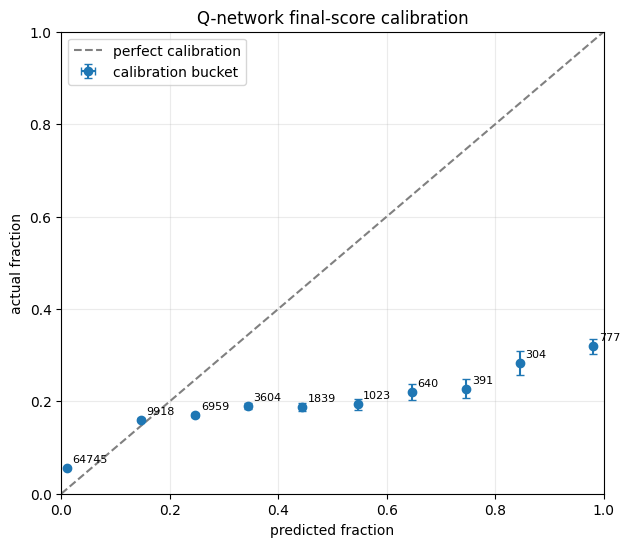

<Figure size 640x480 with 0 Axes>

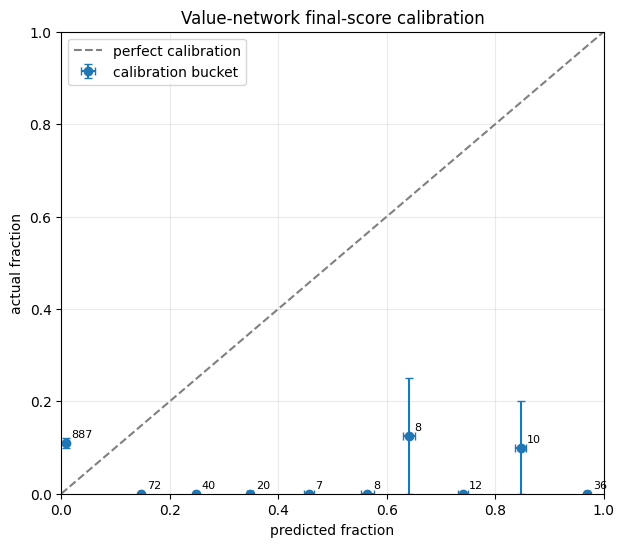

In [6]:
calibration.plot_calibration(q_stats, 'Q-network final-score calibration')
plt.figure()
calibration.plot_calibration(value_stats, 'Value-network final-score calibration')
plt.show()